In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

print("Imports ready.")


Imports ready.


1. Load and Inspect

In [ ]:

csv_path = "/content/Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.xlsx"
print("Using CSV path:", csv_path)

Using CSV path: /content/Superstore_Raw_Data_with_Trade_terms_Second_Project_Need_Cleaning.xlsx


Chcek columsn & rows

In [ ]:
# Peek to confirm headers and basic shape
preview = pd.read_excel(csv_path, nrows=20)
print("Rows (preview):", len(preview))
print("Columns:", list(preview.columns))
preview.head()


Rows (preview): 20
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Purchase Price', 'Sales', 'Quantity', 'Discount', 'Profit', 'COGS', 'Country of Origin', 'Tariff %', 'Tariff', 'Transportation_Cost', 'Inventory_Cost', 'G&A_Expenses', 'FX_Gain_Loss']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,...,Discount,Profit,COGS,Country of Origin,Tariff %,Tariff,Transportation_Cost,Inventory_Cost,G&A_Expenses,FX_Gain_Loss
0,1,CA-2016-152156,42682,42685,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,0.00,19.517606,185.068335,Vietnam,0.12,19.828750,20.95680,22.00464,13.098000,-1.314619
1,2,CA-2016-152156,42682,42685,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,...,0.00,248.164523,337.387477,USA,0.00,0.000000,58.55520,51.23580,36.597000,0.000000
2,3,CA-2016-138688,42533,42537,Second Class,DV-13045,Corporate,United States,Los Angeles,California,...,0.00,3.707266,8.372944,Mexico,0.05,0.398712,1.16960,0.77486,0.731000,0.135670
3,4,US-2015-108966,42288,42295,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,0.45,169.129545,533.680956,China,0.15,69.610559,76.60620,134.06085,47.878875,3.778926
4,5,US-2015-108966,42288,42295,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,...,0.20,5.783205,11.691795,USA,0.00,0.000000,1.78944,1.98516,1.118400,0.000000


2. Data Cleaning and Preparation
Check for missing values and duplicates

In [ ]:

# Check data quality (missing values & duplicates)


# Load the full dataset
df_raw = pd.read_excel(csv_path)

# Quick preview
print("Preview of raw data:")
print(df_raw.head(5))

# Basic info about columns and types
print("\n--- Dataset Info ---")
df_raw.info()

# Count missing values in each column
print("\n--- Missing values by column ---")
print(df_raw.isna().sum())

# Count duplicate rows (entire-row duplicates)
dup_count = df_raw.duplicated().sum()
print(f"\nDuplicate rows found: {dup_count}")

# Drop exact duplicates
if dup_count > 0:
    df_raw = df_raw.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows.")

print(f"\nFinal shape after cleaning duplicates: {df_raw.shape}")


Preview of raw data:
   Row ID        Order ID  Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156       42682      42685    Second Class    CG-12520   
1       2  CA-2016-152156       42682      42685    Second Class    CG-12520   
2       3  CA-2016-138688       42533      42537    Second Class    DV-13045   
3       4  US-2015-108966       42288      42295  Standard Class    SO-20335   
4       5  US-2015-108966       42288      42295  Standard Class    SO-20335   

     Segment        Country             City       State  ...  Discount  \
0   Consumer  United States        Henderson    Kentucky  ...      0.00   
1   Consumer  United States        Henderson    Kentucky  ...      0.00   
2  Corporate  United States      Los Angeles  California  ...      0.00   
3   Consumer  United States  Fort Lauderdale     Florida  ...      0.45   
4   Consumer  United States  Fort Lauderdale     Florida  ...      0.20   

       Profit        COGS Country of Origin Tar

Handling missing values

In [ ]:

# Handle missing values and prepare model-ready view


df = df_raw.copy()

# 1) Dates: convert to datetime (robust to Excel serials)
for c in ["Order Date", "Ship Date"]:
    if c in df.columns:
        if pd.api.types.is_integer_dtype(df[c]) or pd.api.types.is_float_dtype(df[c]):
            # Excel serial -> datetime (origin 1899-12-30)
            ser = pd.to_numeric(df[c], errors="coerce")
            df[c] = pd.to_datetime(ser, unit="D", origin="1899-12-30", errors="coerce")
        else:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# 2) Sales: impute missing by Sub-Category median (fallback to global median)
if {"Sales", "Sub-Category"}.issubset(df.columns):
    miss_mask = df["Sales"].isna()
    if miss_mask.any():
        sub_med = df.groupby("Sub-Category")["Sales"].median()
        df.loc[miss_mask, "Sales"] = df.loc[miss_mask, "Sub-Category"].map(sub_med)
        # global fallback if any remain
        if df["Sales"].isna().any():
            df["Sales"] = df["Sales"].fillna(df["Sales"].median())

# 3) Ship Mode: infer for missing using (Ship Date - Order Date), if both dates exist
if "Ship Mode" in df.columns and df["Ship Mode"].isna().any():
    mask = df["Ship Mode"].isna()
    if {"Ship Date", "Order Date"}.issubset(df.columns):
        day_diff = (df.loc[mask, "Ship Date"] - df.loc[mask, "Order Date"]).dt.days

        def infer_mode(days):
            if pd.isna(days):
                return np.nan
            if days == 0:
                return "Same Day"
            elif days <= 3:
                return "First Class"
            elif days <= 6:
                return "Second Class"
            else:
                return "Standard Class"

        df.loc[mask, "Ship Mode"] = day_diff.apply(infer_mode)

# 4) Tidy categorical text and clip Discount
if "Ship Mode" in df.columns:
    canon = {
        "Same Day": "Same Day",
        "First Class": "First Class",
        "Second Class": "Second Class",
        "Standard Class": "Standard Class",
    }
    df["Ship Mode"] = (
        df["Ship Mode"].astype("string").str.strip().str.title().map(canon).fillna(df["Ship Mode"])
    )

if "Discount" in df.columns:
    df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce").clip(0, 1)

# 5) General safety fills
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if num_cols:

    fill_nums = [c for c in num_cols if c != "Sales"]
    if fill_nums:
        df[fill_nums] = df[fill_nums].apply(lambda s: s.fillna(s.median()))

for c in cat_cols:
    if df[c].isna().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

# 6) Sanity checks
if "Sales" in df.columns:
    # No negative sales: set to median sales if any negatives exist
    neg_sales = (pd.to_numeric(df["Sales"], errors="coerce") < 0).sum()
    if neg_sales:
        df.loc[df["Sales"] < 0, "Sales"] = df["Sales"].median()

# 7) Report remaining missing
print("\nAfter handling missing values:")
post_missing = df.isna().sum()
print(post_missing[post_missing > 0] if (post_missing > 0).any() else "No remaining missing values.")

# Keep a full cleaned copy
df_cleaned = df.copy()

# 8) Model-ready view: narrow to the four required columns with canonical names
df = df_cleaned[["Order Date", "Category", "Sub-Category", "Sales"]].copy()
df = df.rename(columns={
    "Order Date": "date",
    "Category": "category",
    "Sub-Category": "subcategory",
    "Sales": "sales"
})

# Ensure types and drop rows missing key fields
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna(subset=["date", "subcategory", "sales"]).sort_values("date").reset_index(drop=True)

print("\nModel-ready sample (date, category, subcategory, sales):")
print(df.head(5))
print(df.tail(5))
print("Shape:", df.shape)



After handling missing values:
No remaining missing values.

Model-ready sample (date, category, subcategory, sales):
        date         category  subcategory     sales
0 2014-01-03  Office Supplies      Binders  1793.980
1 2014-01-03  Office Supplies        Paper    16.448
2 2014-01-03  Office Supplies      Binders    13.392
3 2014-01-03        Furniture       Tables   393.165
4 2014-01-03       Technology  Accessories    41.900
            date         category  subcategory    sales
49999 2017-12-30  Office Supplies      Binders   13.904
50000 2017-12-30       Technology       Phones  197.970
50001 2017-12-30        Furniture  Furnishings   77.952
50002 2017-12-30  Office Supplies       Labels    6.912
50003 2017-12-30  Office Supplies          Art   34.700
Shape: (50004, 4)


Handling duplicates

In [ ]:
# Deduplicate by business key and rebuild model-ready df

# Work from the cleaned frame if it exists, else from raw
base = df_cleaned.copy() if "df_cleaned" in globals() else df_raw.copy()

# Ensure the business key exists
bk = ["Order ID", "Product ID", "Order Date"]
missing_bk = [c for c in bk if c not in base.columns]
assert not missing_bk, f"Missing columns needed for duplicate handling: {missing_bk}"

# Making sure Order Date is datetime
base["Order Date"] = pd.to_datetime(base["Order Date"], errors="coerce")

before = len(base)

# 1) Find candidate duplicates by the business key
dup_mask = base.duplicated(subset=bk, keep=False)
dups = base.loc[dup_mask].sort_values(bk)

n_groups = dups[bk].drop_duplicates().shape[0]
print(f"Candidate duplicate rows (by {bk}): {dups.shape[0]} across {n_groups} key groups")

# 2) Check if duplicates are truly identical or if non-key fields conflict
nonkey_cols = [c for c in base.columns if c not in bk]
# For each duplicate group, seeing if any non-key column has >1 unique value
conflict_flags = (
    dups.groupby(bk)[nonkey_cols]
        .nunique(dropna=False)
        .max(axis=1)            # max # unique values across all non-key cols
        .gt(1)                  # True if any non-key col differs within the group
)
has_conflicts = conflict_flags.any()
print(f"Conflicting duplicate key groups (non-key fields differ): {int(conflict_flags.sum())}")

# 3) Resolve duplicates
if not has_conflicts:
    # Simple case: duplicates are exact copies → keep first
    df_nodup_full = base.drop_duplicates(subset=bk, keep="first").reset_index(drop=True)
else:
    # Robust case: aggregate to avoid double counting
    # Sum numeric columns (except IDs etc.) took 'first' for non-numerics
    num_cols = base.select_dtypes(include=[np.number]).columns.tolist()
    do_not_sum = {"Row ID", "Postal Code"}
    num_cols = [c for c in num_cols if c not in do_not_sum and c not in bk]

    agg_spec = {c: "sum" for c in num_cols}
    for c in base.columns:
        if c not in bk and c not in agg_spec:
            agg_spec[c] = "first"

    df_nodup_full = (
        base.groupby(bk, dropna=False)
            .agg(agg_spec)
            .reset_index()
    )

removed = before - len(df_nodup_full)
print(f"Duplicates removed: {removed}")

# Keep a cleaned, deduplicated full copy
df_cleaned = df_nodup_full.copy()
# Rebuild the model-ready view for forecasting
# (date, category, subcategory, sales)
df = df_cleaned[["Order Date", "Category", "Sub-Category", "Sales"]].copy()
df = df.rename(columns={
    "Order Date": "date",
    "Category": "category",
    "Sub-Category": "subcategory",
    "Sales": "sales"
})

# Enforce types and drop any rows missing key fields
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df = df.dropna(subset=["date", "subcategory", "sales"]).sort_values("date").reset_index(drop=True)

print("\nModel-ready sample after de-duplication:")
print(df.head(5))
print("Shape:", df.shape)


Candidate duplicate rows (by ['Order ID', 'Product ID', 'Order Date']): 340 across 170 key groups
Conflicting duplicate key groups (non-key fields differ): 170
Duplicates removed: 170

Model-ready sample after de-duplication:
        date         category subcategory    sales
0 2014-01-03  Office Supplies       Paper   16.448
1 2014-01-03        Furniture      Tables  393.165
2 2014-01-03  Office Supplies     Binders   13.392
3 2014-01-03  Office Supplies    Supplies    7.360
4 2014-01-03  Office Supplies       Paper   21.400
Shape: (49834, 4)


Narrow the dataset to timestamp and desired variable to predict / Interpolation if necessary

In [ ]:
# Keep only the columns needed and standardize names
df = pd.read_excel(csv_path)

# Map to expected names for THIS dataset (Superstore-style)
COLUMN_MAP = {
    "date": "Order Date",
    "category": "Category",
    "subcategory": "Sub-Category",
    "sales": "Sales",
    "profit": "Profit"
}

# Rename to canonical lowercase names used downstream
df = df.rename(columns={
    COLUMN_MAP["date"]: "date",
    COLUMN_MAP["category"]: "category",
    COLUMN_MAP["subcategory"]: "subcategory",
    COLUMN_MAP["sales"]: "sales",
    COLUMN_MAP["profit"]: "profit"
})

# Coerce date: handle both Excel serial (e.g., 42682) and normal strings
if np.issubdtype(df["date"].dtype, np.number):
    # Excel serial dates use origin 1899-12-30
    df["date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["date"].round().astype("Int64"), unit="D")
else:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure numeric sales and profit
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df["profit"], errors="coerce")

# Drop rows with missing key fields
df = df.dropna(subset=["date", "subcategory", "sales", "profit"])

# Basic sanity: set negative sales or profit to zero (defensible for this assignment)
neg_sales = (df["sales"] < 0).sum()
neg_profit = (df["profit"] < 0).sum()

if neg_sales > 0:
    print(f"Warning: {neg_sales} negative sales found. Setting to zero for analysis.")
    df.loc[df["sales"] < 0, "sales"] = 0.0
if neg_profit > 0:
    print(f"Warning: {neg_profit} negative profits found. Setting to zero for analysis.")
    df.loc[df["profit"] < 0, "profit"] = 0.0

# Sort and keep only required columns
df = df[["date", "category", "subcategory", "sales", "profit"]].sort_values("date").reset_index(drop=True)

# 4) Zero-fill diagnostics
zero_sales = (df["sales"] == 0).sum()
zero_profit = (df["profit"] == 0).sum()
total_rows = len(df)

print(f"\nZero-sale months: {zero_sales:,} out of {total_rows:,} total "
      f"({zero_sales / total_rows:.2%} of all records)")
print(f"Zero-profit months: {zero_profit:,} out of {total_rows:,} total "
      f"({zero_profit / total_rows:.2%} of all records)")

zero_by_sub = (
    df.groupby("subcategory")[["sales", "profit"]]
    .apply(lambda s: pd.Series({
        "zero_sales": (s["sales"] == 0).sum(),
        "zero_profit": (s["profit"] == 0).sum()
    }))
    .reset_index()
    .sort_values("zero_sales", ascending=False)
)

print("\nSubcategories with most zero-sale or zero-profit months:")
print(zero_by_sub.head(10))

print("\nCleaned sample:")
df.head()



Zero-sale months: 0 out of 50,002 total (0.00% of all records)
Zero-profit months: 421 out of 50,002 total (0.84% of all records)

Subcategories with most zero-sale or zero-profit months:
   subcategory  zero_sales  zero_profit
0  Accessories           0           14
1   Appliances           0           96
2          Art           0           25
3      Binders           0          124
4    Bookcases           0           18
5       Chairs           0            0
6      Copiers           0            0
7    Envelopes           0            3
8    Fasteners           0           11
9  Furnishings           0           90

Cleaned sample:


,date,category,subcategory,sales,profit
0,2014-01-03,Office Supplies,Paper,21.400,7.199378
1,2014-01-03,Office Supplies,Supplies,7.360,1.848766
2,2014-01-03,Office Supplies,Binders,1793.980,653.234136
3,2014-01-03,Office Supplies,Binders,13.392,3.902005
4,2014-01-03,Furniture,Tables,393.165,50.959775


convert daily to monthly and aggregate by subcategory

In [ ]:
# making sure 'date' is datetime and numeric cols are numeric
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["sales"] = pd.to_numeric(df["sales"], errors="coerce")
df["profit"] = pd.to_numeric(df.get("profit"), errors="coerce")  # handles if 'profit' exists
df = df.dropna(subset=["date", "subcategory", "sales", "profit"])

# create a month-start timestamp
df["year_month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# aggregate to monthly sales & profit per subcategory
monthly = (
    df.groupby(["subcategory", "year_month"], as_index=False)[["sales", "profit"]]
      .sum()
      .rename(columns={"year_month": "timestamp"})
      .sort_values(["subcategory", "timestamp"])
      .reset_index(drop=True)
)

# missing months will be filled with 0 for both sales and profit
all_months = pd.date_range(monthly["timestamp"].min(), monthly["timestamp"].max(), freq="MS")
filled = []
for sub in monthly["subcategory"].unique():
    tmp = monthly.loc[monthly["subcategory"] == sub, ["timestamp", "sales", "profit"]].set_index("timestamp")
    tmp = tmp.reindex(all_months, fill_value=0.0)
    tmp = tmp.rename_axis("timestamp").reset_index()
    tmp["subcategory"] = sub
    filled.append(tmp)

data_m = (
    pd.concat(filled, ignore_index=True)[["subcategory", "timestamp", "sales", "profit"]]
      .sort_values(["subcategory", "timestamp"])
      .reset_index(drop=True)
)

print("Monthly sample:")
print(data_m.head(10))
print("\nShape:", data_m.shape)
print("Unique subcategories:", data_m["subcategory"].nunique())

# Zero-fill diagnostics
zero_sales_count = (data_m["sales"] == 0).sum()
zero_profit_count = (data_m["profit"] == 0).sum()
total_rows = len(data_m)

print(f"\nZero-sale months: {zero_sales_count:,} out of {total_rows:,} total "
      f"({zero_sales_count / total_rows:.2%})")
print(f"Zero-profit months: {zero_profit_count:,} out of {total_rows:,} total "
      f"({zero_profit_count / total_rows:.2%})")

zero_by_sub = (
    data_m.groupby("subcategory")
          .agg(
              zero_sales=("sales", lambda s: (s == 0).sum()),
              zero_profit=("profit", lambda s: (s == 0).sum())
          )
          .reset_index()
          .sort_values(["zero_sales", "zero_profit"], ascending=False)
)
print("\nSubcategories with most zero months (sales/profit):")
print(zero_by_sub.head(10))


# optional: zero share per subcategory (both metrics)
zero_share_by_sub = (
    data_m.assign(is_zero_sales=data_m["sales"] == 0,
                  is_zero_profit=data_m["profit"] == 0)
          .groupby("subcategory")
          .agg(
              zero_sales_months=("is_zero_sales", "sum"),
              zero_profit_months=("is_zero_profit", "sum"),
              total_months=("is_zero_sales", "size")
          )
          .assign(
              zero_sales_share=lambda d: d["zero_sales_months"] / d["total_months"],
              zero_profit_share=lambda d: d["zero_profit_months"] / d["total_months"]
          )
          .sort_values(["zero_sales_share", "zero_profit_share"], ascending=False)
          .reset_index()
)
print("\nSubcategories by zero-month share (sales/profit):")
print(zero_share_by_sub.head(10))


Monthly sample:
   subcategory  timestamp      sales       profit
0  Accessories 2014-01-01  12451.996  3465.674506
1  Accessories 2014-02-01   2914.812   866.603550
2  Accessories 2014-03-01  12459.782  3313.223403
3  Accessories 2014-04-01  12062.796  3312.774747
4  Accessories 2014-05-01  12999.688  3513.273562
5  Accessories 2014-06-01   9674.224  2597.630857
6  Accessories 2014-07-01  11657.552  2779.836751
7  Accessories 2014-08-01  11704.982  3194.520459
8  Accessories 2014-09-01  20896.316  5851.118841
9  Accessories 2014-10-01  11008.874  2953.510144

Shape: (816, 4)
Unique subcategories: 17

Zero-sale months: 2 out of 816 total (0.25%)
Zero-profit months: 2 out of 816 total (0.25%)

Subcategories with most zero months (sales/profit):
   subcategory  zero_sales  zero_profit
6      Copiers           2            2
0  Accessories           0            0
1   Appliances           0            0
2          Art           0            0
3      Binders           0            0
4    B

winsorization (optionl)

In [ ]:
# Winsorization (cap outliers per subcategory)

def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    """Clip a series between the 1st and 99th percentile by default."""
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)
data_m["sales_w"] = (
    data_m.groupby("subcategory", group_keys=False)["sales"]
          .apply(lambda s: winsorize_series(s, 0.01, 0.99))
)

data_m["profit_w"] = (
    data_m.groupby("subcategory", group_keys=False)["profit"]
          .apply(lambda s: winsorize_series(s, 0.01, 0.99))
)

# Identify changed values
sales_changed_mask = data_m["sales_w"].ne(data_m["sales"]) & data_m["sales"].notna()
profit_changed_mask = data_m["profit_w"].ne(data_m["profit"]) & data_m["profit"].notna()

sales_changed_rows = data_m.loc[sales_changed_mask, ["subcategory", "timestamp", "sales", "sales_w"]]
profit_changed_rows = data_m.loc[profit_changed_mask, ["subcategory", "timestamp", "profit", "profit_w"]]

num_sales_changed = int(sales_changed_mask.sum())
num_profit_changed = int(profit_changed_mask.sum())

print(f"\nWinsorization complete.")
print(f"Sales clipped: {num_sales_changed:,} values.")
print(f"Profit clipped: {num_profit_changed:,} values.")

if num_sales_changed > 0:
    print("\nRows with changed sales:")
    print(sales_changed_rows.head(10))
else:
    print("No sales values were clipped.")

if num_profit_changed > 0:
    print("\nRows with changed profit:")
    print(profit_changed_rows.head(10))
else:
    print("No profit values were clipped.")

# Choosing which column to model later
TARGET_COL_SALES = "sales_w"
TARGET_COL_PROFIT = "profit_w"



Winsorization complete.
Sales clipped: 33 values.
Profit clipped: 33 values.

Rows with changed sales:
     subcategory  timestamp       sales       sales_w
1    Accessories 2014-02-01   2914.8120   3604.297300
44   Accessories 2017-09-01  39105.4100  38958.566960
49    Appliances 2014-02-01    737.9580   1121.541920
95    Appliances 2017-12-01  26952.0460  26522.212200
97           Art 2014-02-01    444.6240    546.808580
142          Art 2017-11-01   6008.3780   5891.880040
156      Binders 2015-01-01   3024.5930   3563.756320
188      Binders 2017-09-01  54945.7640  54891.919390
193    Bookcases 2014-02-01   2649.0352   2824.668936
239    Bookcases 2017-12-01  24951.4282  24456.818859

Rows with changed profit:
     subcategory  timestamp        profit      profit_w
1    Accessories 2014-02-01    866.603550   1044.826412
44   Accessories 2017-09-01  10695.162112  10297.420814
49    Appliances 2014-02-01    249.832193    359.714724
94    Appliances 2017-11-01   8431.808117   8247.93

3. Profitability filter

In [ ]:
# Identify the five most profitable subcategories over the historical period
if "profit" in data_m.columns and data_m["profit"].notna().any():
    # Use total profit as the metric
    totals = (
        data_m.groupby("subcategory", as_index=False)["profit"]
              .sum()
              .sort_values("profit", ascending=False)
    )
    metric_used = "profit"
else:
    # Fallback: use sales as a proxy for profitability
    totals = (
        data_m.groupby("subcategory", as_index=False)["sales"]
              .sum()
              .sort_values("sales", ascending=False)
    )
    metric_used = "sales (proxy for profit)"
    print("Note: Profit data unavailable. Using total sales as a proxy for profitability.")

top5 = totals.head(5)["subcategory"].tolist()

print(f"Top 5 subcategories by total {metric_used}:")
print(top5)
totals.head()

Top 5 subcategories by total profit:
['Phones', 'Chairs', 'Storage', 'Binders', 'Machines']


,subcategory,profit
13,Phones,427270.437598
5,Chairs,365412.704542
14,Storage,331206.117500
3,Binders,302053.957467
11,Machines,239108.186157


Forecasting Methods


Selected final model per subcategory by lowest average Test RMSE
Binders: Holt Winters
Chairs: Seasonal Naive
Machines: Holt Winters
Phones: Holt Winters
Storage: Holt Winters


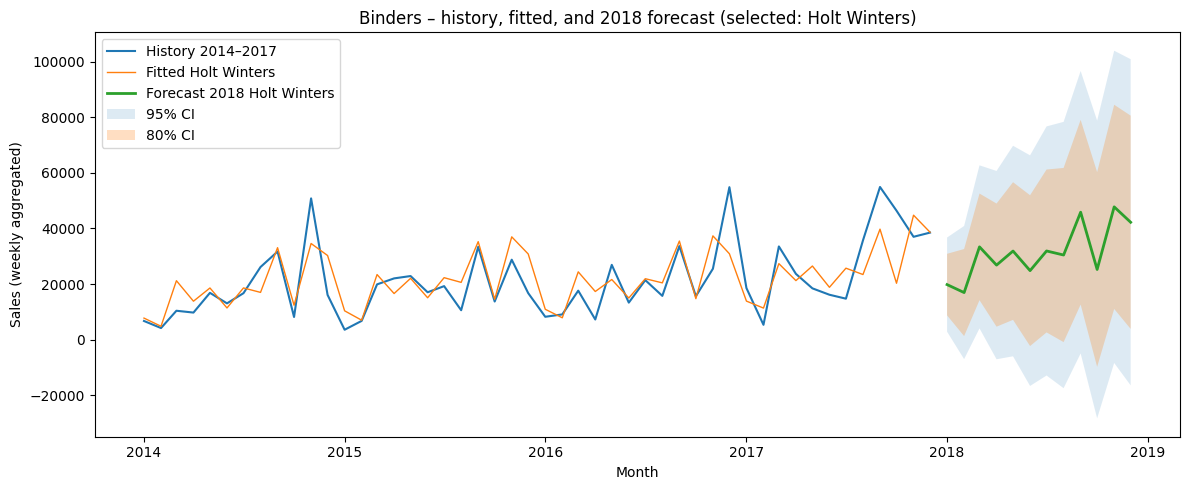

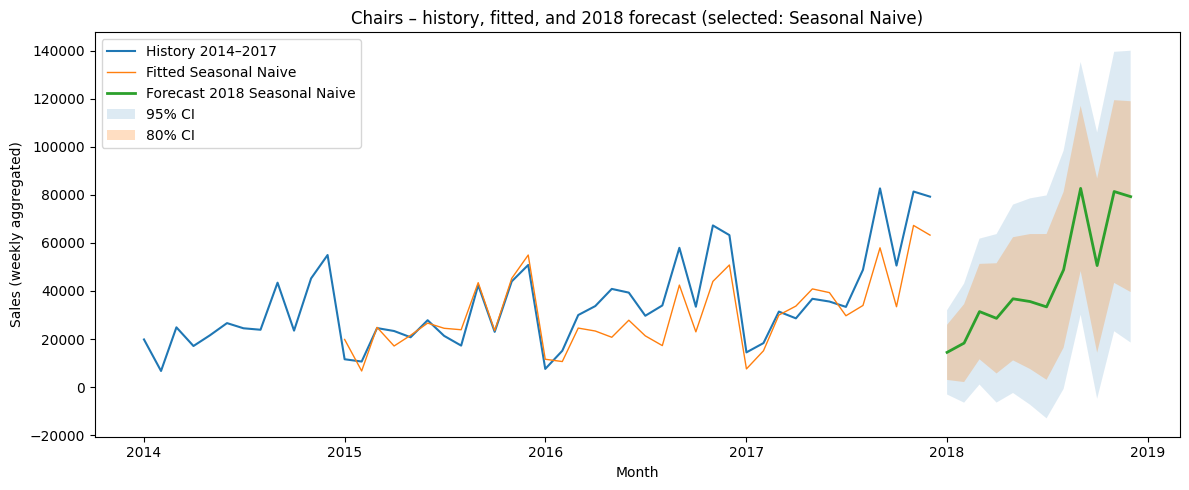

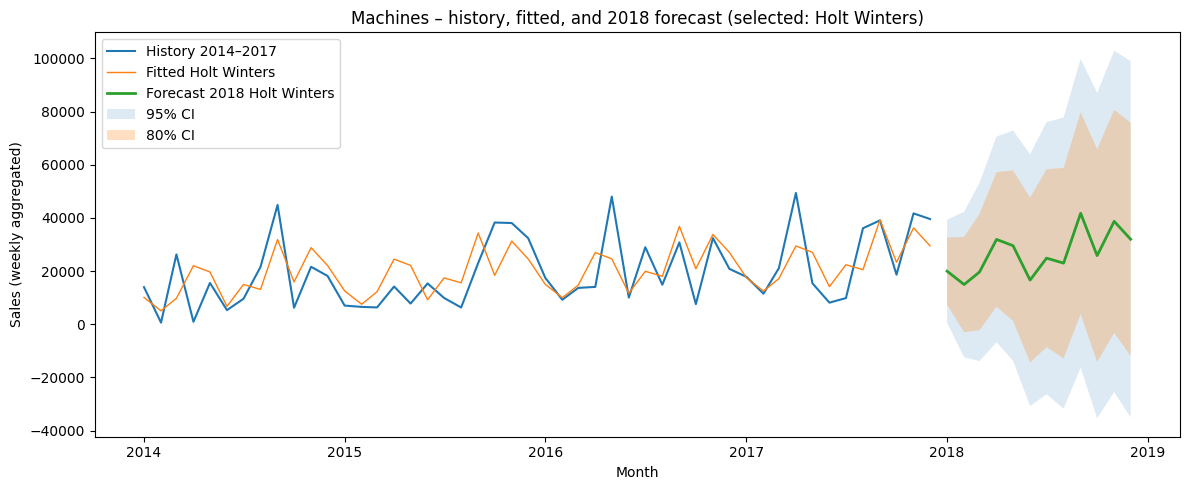

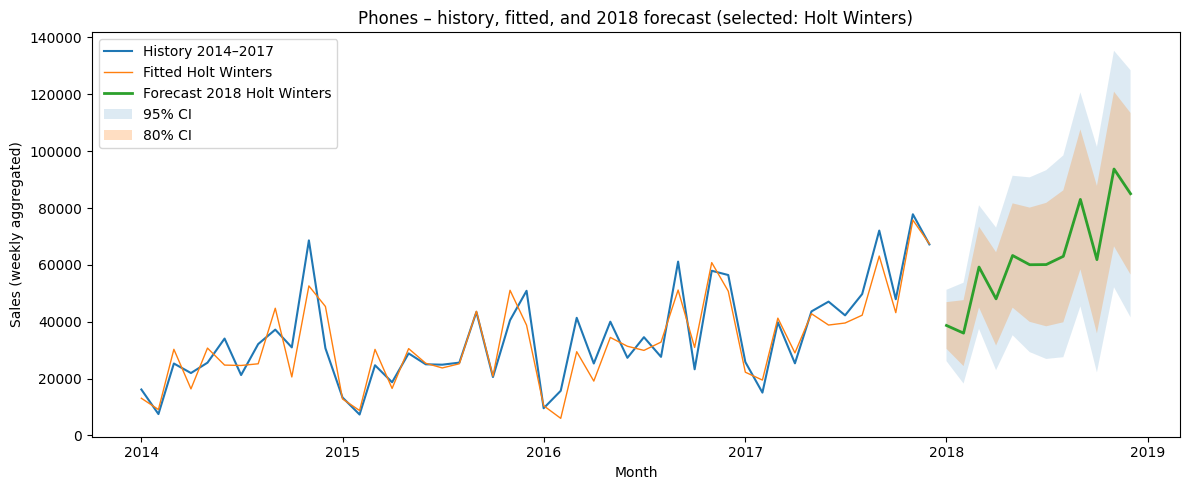

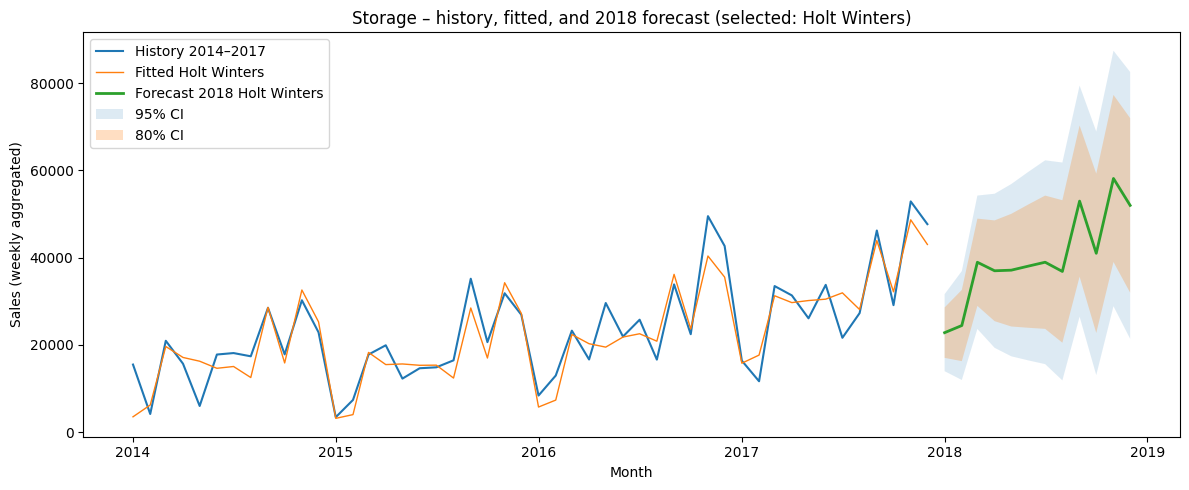


Average metrics across folds by model (Train vs Test)
                                 MAE             MAPE              RMSE  \
FoldType                        Test     Train   Test   Train      Test   
Subcategory Model                                                         
Binders     Holt Winters     8401.19   4485.17  41.82   28.54   9510.35   
            Seasonal Naive  10882.30   7220.47  51.53   45.28  12376.36   
            XGBoost         11821.70     26.59  62.36    0.16  14367.30   
Chairs      Holt Winters    13171.57   2656.62  39.02   13.31  14227.17   
            Seasonal Naive   9494.80   5810.30  25.69   22.45  10530.42   
            XGBoost         18887.04     19.92  80.82    0.10  24050.99   
Machines    Holt Winters     9955.64   7635.03  43.68  118.38  13632.29   
            Seasonal Naive  12996.47  13281.94  58.27   94.18  17615.57   
            XGBoost          9635.23     17.93  36.25    0.14  14300.13   
Phones      Holt Winters     7601.15   4849.3

In [ ]:
# Model selection by metrics + future forecasts with plots
# Chooses best model per subcategory by lowest average Test RMSE, then forecasts 2018
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEASONAL_PERIODS = 12
FORECAST_HORIZON = 12
LOOKBACK_M = 60
PLOT_FIGSIZE = (12, 5)

# Backtest folds within 2014–2017
FOLDS = [
    # Train up to 2015-12, Test 2016-H1
    ("2014-01-01", "2015-12-31", "2016-01-01", "2016-06-30"),
    # Train up to 2016-12, Test 2017-H1
    ("2014-01-01", "2016-12-31", "2017-01-01", "2017-06-30"),
    # Train up to 2017-06, Test 2017-H2
    ("2014-01-01", "2017-06-30", "2017-07-01", "2017-12-31"),
]

# Metrics

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def eval_metrics(y_true, y_pred, label):
    return {
        "Model": label,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred)
    }


# Seasonal Naive

def seasonal_naive_forecast(train_series, forecast_index, seasonal_periods=12):
    if len(train_series) == 0:
        return np.full(len(forecast_index), np.nan)
    vals = []
    for ts in forecast_index:
        src = ts - pd.DateOffset(months=seasonal_periods)
        vals.append(train_series.loc[src] if src in train_series.index else train_series.iloc[-1])
    return np.array(vals)

def seasonal_naive_insample(train_series, seasonal_periods=12):
    idx = train_series.index
    fitted = []
    for t in range(len(idx)):
        src_pos = t - seasonal_periods
        fitted.append(train_series.iloc[src_pos] if src_pos >= 0 else np.nan)
    return pd.Series(fitted, index=idx)

# XGBoost (aligned with class; compatible with older xgboost)
def make_time_features(idx: pd.DatetimeIndex) -> pd.DataFrame:
    X = pd.DataFrame(index=idx)
    X["year"] = X.index.year
    X["month"] = X.index.month
    X["month_sin"] = np.sin(2*np.pi*X["month"]/12.0)
    X["month_cos"] = np.cos(2*np.pi*X["month"]/12.0)
    return X

def make_lag_features(y: pd.Series, max_lag=12, windows=(3,6,12)) -> pd.DataFrame:
    X = pd.DataFrame(index=y.index)
    for l in range(1, max_lag+1):
        X[f"lag_{l}"] = y.shift(l)
    for w in windows:
        X[f"roll_mean_{w}"] = y.shift(1).rolling(w).mean()
    return X

def _xgb_model():
    # move eval_metric into constructor; avoid eval_metric/early_stopping in fit()
    return XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        reg_alpha=1.0,
        eval_metric="rmse",
        random_state=42
    )

def xgb_fit_predict_aligned(train_series: pd.Series,
                            test_index: pd.DatetimeIndex,
                            lookback_m: int = LOOKBACK_M):
    """
    Train on recent LOOKBACK_M months using lag1..lag12, rolling means (3,6,12), and calendar features.
    Returns in-sample fitted (on supervised rows) and recursive predictions for the test_index.
    """
    train_series = train_series.asfreq("MS").astype(float).dropna()
    if len(train_series) == 0:
        return pd.Series(dtype=float), pd.Series(dtype=float), None

    y_hist = train_series.iloc[-lookback_m:] if len(train_series) > lookback_m else train_series
    X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
    X_cal = make_time_features(y_hist.index)
    X_sup = pd.concat([X_lag, X_cal], axis=1)
    XY = pd.concat([X_sup, y_hist.rename("y")], axis=1).dropna()

    if len(XY) < 12:
        return pd.Series(dtype=float), pd.Series(dtype=float), None

    X_train = XY.drop(columns=["y"])
    y_train = XY["y"]

    model = _xgb_model()
    model.fit(X_train, y_train)

    y_hat_train = pd.Series(model.predict(X_train), index=X_train.index)

    if len(test_index) == 0:
        return y_hat_train, pd.Series(dtype=float), model

    # recursive over test_index
    y_roll = y_hist.copy()
    preds = []
    for dt_i in pd.DatetimeIndex(sorted(test_index)):
        X_l_full = make_lag_features(y_roll, max_lag=12, windows=(3,6,12))
        row_lag = X_l_full.iloc[[-1]]
        row_cal = make_time_features(pd.DatetimeIndex([dt_i]))
        X_row = pd.concat([row_lag.reset_index(drop=True),
                           row_cal.reset_index(drop=True)], axis=1)
        # align columns
        missing_cols = [c for c in X_train.columns if c not in X_row.columns]
        for c in missing_cols:
            X_row[c] = 0.0
        X_row = X_row[X_train.columns]

        y_pred = float(model.predict(X_row)[0])
        preds.append((dt_i, y_pred))
        y_roll = pd.concat([y_roll, pd.Series([y_pred], index=[dt_i])])

    y_hat_test = pd.Series({dt: val for dt, val in preds}).sort_index()
    return y_hat_train, y_hat_test, model

def xgb_recursive_forecast_aligned(history_series: pd.Series,
                                   steps: int = FORECAST_HORIZON,
                                   lookback_m: int = LOOKBACK_M):
    """
    Final forward forecast using aligned features and recursive roll.
    Returns fc_mean, fc_lw95, fc_up95 with sigma from in-sample residuals.
    """
    history_series = history_series.asfreq("MS").astype(float).dropna()
    if len(history_series) == 0:
        future_idx = pd.date_range(history_series.index[-1] + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
        nan = pd.Series(index=future_idx, data=np.nan)
        return nan, nan, nan

    y_hist = history_series.iloc[-lookback_m:] if len(history_series) > lookback_m else history_series
    X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
    X_cal = make_time_features(y_hist.index)
    X_sup = pd.concat([X_lag, X_cal], axis=1)
    XY = pd.concat([X_sup, y_hist.rename("y")], axis=1).dropna()

    if len(XY) < 12:
        future_idx = pd.date_range(y_hist.index.max() + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
        nan = pd.Series(index=future_idx, data=np.nan)
        return nan, nan, nan

    X_train = XY.drop(columns=["y"])
    y_train = XY["y"]
    model = _xgb_model()
    model.fit(X_train, y_train)

    # residual sigma for PI
    train_pred = pd.Series(model.predict(X_train), index=X_train.index)
    resid = (y_train.loc[train_pred.index] - train_pred).dropna()
    sigma = resid.std(ddof=1) if len(resid) > 1 else 0.0
    z = 1.96

    last_date = y_hist.index.max()
    future_idx = pd.date_range(last_date + pd.offsets.MonthBegin(1), periods=steps, freq="MS")
    y_roll = y_hist.copy()
    preds = []
    for dt_i in future_idx:
        X_l_full = make_lag_features(y_roll, max_lag=12, windows=(3,6,12))
        row_lag  = X_l_full.iloc[[-1]]
        row_cal  = make_time_features(pd.DatetimeIndex([dt_i]))
        X_row = pd.concat([row_lag.reset_index(drop=True), row_cal.reset_index(drop=True)], axis=1)
        missing_cols = [c for c in X_train.columns if c not in X_row.columns]
        for c in missing_cols:
            X_row[c] = 0.0
        X_row = X_row[X_train.columns]
        pred = float(model.predict(X_row)[0])
        preds.append(pred)
        y_roll = pd.concat([y_roll, pd.Series([pred], index=[dt_i])])

    fc_mean = pd.Series(preds, index=future_idx)
    fc_lw95 = fc_mean - z * sigma
    fc_up95 = fc_mean + z * sigma
    return fc_mean, fc_lw95, fc_up95

# Gaussian intervals helper

def gaussian_pi_from_residuals(forecast_series, resid, horizon, inflate=True):
    sigma = np.nanstd(resid, ddof=1)
    h = np.arange(1, horizon + 1)
    scale = np.sqrt(h) if inflate else 1.0
    z80, z95 = 1.2815515655446004, 1.959963984540054
    idx = forecast_series.index
    lw80 = forecast_series.values - z80 * sigma * scale
    up80 = forecast_series.values + z80 * sigma * scale
    lw95 = forecast_series.values - z95 * sigma * scale
    up95 = forecast_series.values + z95 * sigma * scale
    return {
        "lw80": pd.Series(lw80, index=idx),
        "up80": pd.Series(up80, index=idx),
        "lw95": pd.Series(lw95, index=idx),
        "up95": pd.Series(up95, index=idx),
    }

# Data prep
data_m = data_m.copy()
data_m["timestamp"] = pd.to_datetime(data_m["timestamp"])

# Backtests

rows = []
for sub in top5:
    s = (
        data_m.loc[data_m["subcategory"] == sub, ["timestamp", "sales_w"]]
        .set_index("timestamp")
        .asfreq("MS")
        .sort_index()["sales_w"]
    ).loc["2014-01-01":"2017-12-31"].dropna()
    if s.empty or len(s) < 24:
        continue

    for tr_start, tr_end, te_start, te_end in FOLDS:
        train = s.loc[tr_start:tr_end]
        test  = s.loc[te_start:te_end]
        if len(train) < SEASONAL_PERIODS + 1 or len(test) == 0:
            continue

        # Seasonal Naive
        sn_fit = seasonal_naive_insample(train, SEASONAL_PERIODS).dropna()
        sn_fc  = seasonal_naive_forecast(train, test.index, SEASONAL_PERIODS)
        rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Seasonal Naive",
                     **eval_metrics(train.loc[sn_fit.index], sn_fit, "Seasonal Naive")})
        rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Seasonal Naive",
                     **eval_metrics(test, sn_fc, "Seasonal Naive")})

        # Holt-Winters
        try:
            hw = ExponentialSmoothing(train, trend="add", seasonal="add",
                                      seasonal_periods=SEASONAL_PERIODS).fit(optimized=True)
            hw_fit = pd.Series(hw.fittedvalues, index=train.index)
            hw_fc  = hw.forecast(len(test))
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Holt Winters",
                         **eval_metrics(train, hw_fit, "Holt Winters")})
            rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Holt Winters",
                         **eval_metrics(test, hw_fc, "Holt Winters")})
        except Exception:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "Holt Winters",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})
            rows.append({"Subcategory": sub, "FoldType": "Test",  "Model": "Holt Winters",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})

        # XGBoost aligned
        xgb_tr_hat, xgb_te_hat, _ = xgb_fit_predict_aligned(train, test.index, LOOKBACK_M)
        if not xgb_tr_hat.empty:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "XGBoost",
                         **eval_metrics(train.loc[xgb_tr_hat.index], xgb_tr_hat, "XGBoost")})
        else:
            rows.append({"Subcategory": sub, "FoldType": "Train", "Model": "XGBoost",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})
        if not xgb_te_hat.empty:
            rows.append({"Subcategory": sub, "FoldType": "Test", "Model": "XGBoost",
                         **eval_metrics(test.loc[xgb_te_hat.index], xgb_te_hat, "XGBoost")})
        else:
            rows.append({"Subcategory": sub, "FoldType": "Test", "Model": "XGBoost",
                         "MAE": np.nan, "RMSE": np.nan, "MAPE": np.nan})

metrics_df = pd.DataFrame(rows)
if metrics_df.empty:
    raise ValueError("No metrics computed")

# Select best model by lowest average Test RMSE (tie-break by MAPE)
avg_metrics = (
    metrics_df.groupby(["Subcategory", "Model", "FoldType"])
    .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), MAPE=("MAPE","mean"))
    .reset_index()
)

winners = {}
for sub in avg_metrics["Subcategory"].unique():
    sub_test = avg_metrics[(avg_metrics["Subcategory"]==sub) & (avg_metrics["FoldType"]=="Test")].copy()
    if sub_test.empty:
        continue
    sub_test = sub_test.sort_values(["RMSE","MAPE"], ascending=[True, True])
    winners[sub] = sub_test.iloc[0]["Model"]

print("\nSelected final model per subcategory by lowest average Test RMSE")
for k,v in winners.items():
    print(f"{k}: {v}")

# Fit chosen model on full history and forecast 2018
final_objs = {}
for sub, model_name in winners.items():
    s_full = (
        data_m.loc[data_m["subcategory"] == sub, ["timestamp", "sales_w"]]
        .set_index("timestamp")
        .asfreq("MS")
        .sort_index()["sales_w"]
    ).loc["2014-01-01":"2017-12-31"].dropna()
    if s_full.empty:
        continue

    idx_future = pd.date_range("2018-01-01", periods=FORECAST_HORIZON, freq="MS")

    if model_name == "Holt Winters":
        hw = ExponentialSmoothing(s_full, trend="add", seasonal="add",
                                  seasonal_periods=SEASONAL_PERIODS).fit(optimized=True)
        fitted_full = pd.Series(hw.fittedvalues, index=s_full.index)
        fc = hw.forecast(FORECAST_HORIZON).reindex(idx_future)
        resid = (s_full - fitted_full).dropna()
        pis = gaussian_pi_from_residuals(fc, resid, FORECAST_HORIZON, inflate=True)
        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": fc,
                           "lw80": pis["lw80"], "up80": pis["up80"], "lw95": pis["lw95"], "up95": pis["up95"]}

    elif model_name == "Seasonal Naive":
        fitted_full = seasonal_naive_insample(s_full, SEASONAL_PERIODS)
        fc_vals = seasonal_naive_forecast(s_full, idx_future, SEASONAL_PERIODS)
        fc = pd.Series(fc_vals, index=idx_future)
        resid = (s_full.loc[fitted_full.dropna().index] - fitted_full.dropna())
        pis = gaussian_pi_from_residuals(fc, resid, FORECAST_HORIZON, inflate=True)
        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": fc,
                           "lw80": pis["lw80"], "up80": pis["up80"], "lw95": pis["lw95"], "up95": pis["up95"]}

    else:  # XGBoost
        xgb_fc_mean, xgb_lw95, xgb_up95 = xgb_recursive_forecast_aligned(
            s_full, steps=FORECAST_HORIZON, lookback_m=LOOKBACK_M
        )
        # in-sample fitted on supervised rows for plotting
        y_hist = s_full.iloc[-LOOKBACK_M:] if len(s_full) > LOOKBACK_M else s_full
        X_lag = make_lag_features(y_hist, max_lag=12, windows=(3,6,12))
        X_cal = make_time_features(y_hist.index)
        XY = pd.concat([X_lag, X_cal, y_hist.rename("y")], axis=1).dropna()
        if len(XY) >= 12:
            X_train = XY.drop(columns=["y"])
            y_train = XY["y"]
            mdl = _xgb_model()
            mdl.fit(X_train, y_train)
            fitted_vals = pd.Series(mdl.predict(X_train), index=X_train.index)
            fitted_full = pd.Series(index=s_full.index, dtype=float)
            fitted_full.loc[fitted_vals.index] = fitted_vals.values
        else:
            fitted_full = pd.Series(index=s_full.index, data=np.nan)

        final_objs[sub] = {"model": model_name, "history": s_full, "fitted": fitted_full, "forecast": xgb_fc_mean,
                           "lw80": xgb_lw95 + 0.0, "up80": xgb_up95 + 0.0,  # reuse 95% if 80% not available
                           "lw95": xgb_lw95, "up95": xgb_up95}

# Visualization

for sub, obj in final_objs.items():
    plt.figure(figsize=PLOT_FIGSIZE)
    plt.plot(obj["history"].index, obj["history"].values, label="History 2014–2017", linewidth=1.5)
    if obj["fitted"].notna().sum() > 0:
        plt.plot(obj["fitted"].index, obj["fitted"].values, label=f"Fitted {obj['model']}", linewidth=1)
    plt.plot(obj["forecast"].index, obj["forecast"].values, label=f"Forecast 2018 {obj['model']}", linewidth=2)
    if obj["lw95"].notna().sum() and obj["up95"].notna().sum():
        plt.fill_between(obj["forecast"].index, obj["lw95"].values, obj["up95"].values, alpha=0.15, label="95% CI")
    if obj["lw80"].notna().sum() and obj["up80"].notna().sum():
        plt.fill_between(obj["forecast"].index, obj["lw80"].values, obj["up80"].values, alpha=0.25, label="80% CI")
    plt.title(f"{sub} – history, fitted, and 2018 forecast (selected: {obj['model']})")
    plt.xlabel("Month")
    plt.ylabel("Sales (weekly aggregated)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Comparison table
print("\nAverage metrics across folds by model (Train vs Test)")
avg_tbl = (
    metrics_df.groupby(["Subcategory","Model","FoldType"])
    .agg(MAE=("MAE","mean"), RMSE=("RMSE","mean"), MAPE=("MAPE","mean"))
    .round(2)
    .reset_index()
)
print(
    avg_tbl.pivot_table(
        index=["Subcategory","Model"],
        columns="FoldType",
        values=["MAE","RMSE","MAPE"]
    )
)


Interpretation of metrics

In [ ]:

# Summarize metrics for the selected (best) model per subcategory
print("\nFinal selected model metrics (average across backtest folds):")
best_metrics_rows = []
for sub, mdl in winners.items():
    subset = avg_metrics[(avg_metrics["Subcategory"] == sub) &
                         (avg_metrics["Model"] == mdl) &
                         (avg_metrics["FoldType"] == "Test")]
    if subset.empty:
        continue
    row = subset[["Subcategory", "Model", "MAE", "RMSE", "MAPE"]].iloc[0]
    best_metrics_rows.append(row)

best_metrics_df = pd.DataFrame(best_metrics_rows).reset_index(drop=True)
best_metrics_df = best_metrics_df.round(2)
print(best_metrics_df.to_string(index=False))



Final selected model metrics (average across backtest folds):
Subcategory          Model     MAE     RMSE  MAPE
    Binders   Holt Winters 8401.19  9510.35 41.82
     Chairs Seasonal Naive 9494.80 10530.42 25.69
   Machines   Holt Winters 9955.64 13632.29 43.68
     Phones   Holt Winters 7601.15  8705.04 22.62
    Storage   Holt Winters 5012.10  6481.91 22.89


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

6. Sensitivity / Assumptions

1. Data Filtering & Frequency

Time frame: Forecasting uses data from January 2014 through December 2017 as the historical period.
Earlier years (if present) are excluded to ensure consistent reporting frequency and stable seasonality.

Frequency: All series are converted to a monthly start (“MS”) frequency using asfreq("MS").
Missing months are treated as zero or NaN and removed before modeling.

Subcategories: Only the top-performing product subcategories (top5) are modeled (Binders, Chairs, Phones, Storage, Machines).

2. Seasonality & Trend Assumptions

The sales data exhibit clear annual (12-month) seasonality, consistent with retail sales cycles.

Seasonal period (m): 12 months is assumed across all models.

Trend: Where applicable (e.g., Holt-Winters), the trend is modeled additively (“add”) rather than multiplicatively, assuming linear growth patterns.

Deseasonalization: Not applied explicitly; seasonality is handled internally by each model.

3. Model Configurations

Seasonal Naïve:
Forecasts repeat the sales value from the same month one year prior (t − 12).
No parameters are optimized; serves as a benchmark model.

Holt-Winters (Additive):
trend="add", seasonal="add", seasonal_periods=12, optimized=True
Automatically estimates smoothing parameters α, β, γ through internal optimization.
Additive components assume constant seasonal amplitude and linear trend.

XGBoost Regressor:
Used with recent 60 months (LOOKBACK_M = 60) of data, incorporating:

Lags: 1–12 months

Rolling means: 3, 6, and 12 months

Calendar features: year, month, sine and cosine seasonal encodings
Hyperparameters:

n_estimators = 400
learning_rate = 0.05
max_depth = 3
subsample = 0.8
colsample_bytree = 0.8
reg_lambda = 2.0
reg_alpha = 1.0


Residual standard deviation (σ) from in-sample errors used for ±95% prediction intervals.

4. Model Comparison & Selection

Evaluation metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), Mean Absolute Percentage Error (MAPE).

Cross-validation: Rolling-origin backtesting across 3 folds:

Train through 2015 → test 2016H1

Train through 2016 → test 2017H1

Train through 2017H1 → test 2017H2

Selection rule: The model with the lowest average Test RMSE across folds is chosen per subcategory.

5. Forecast Horizon & Intervals

Forecast period: 12 months (January–December 2018).

Confidence intervals:

Holt-Winters and Seasonal Naïve: Gaussian intervals from in-sample residual standard deviation (80% and 95%).

XGBoost: ±1.96 × σ (approx. 95%) from training residuals.

Inflation: Intervals widened with √h scaling for increasing forecast horizon uncertainty.

6. Sensitivity Considerations

Results are sensitive to the seasonal period (12) and lookback window (60 months).
Shorter windows reduce trend estimation accuracy; longer windows risk structural shifts.

Additive seasonality assumes consistent amplitude — multiplicative structure might improve fit for high-growth subcategories.

XGBoost forecasts are more sensitive to lag feature construction and the presence of recent outliers.

Holt-Winters smoothing may underperform if sudden structural breaks occur after 2017.